## Лабораторна робота 5. **CLASSIFICATION** 🔵/🔺

Оцінювання даної роботи буде ураховувати якість Ваших висновків та візуалізацій. При наявності ЛИШЕ коду та візуалізацій без роз'яснень, робота оцінюватися НЕ БУДЕ.  

Більшість поставлених в цій лабораторній роботі задач в майбутньому буде ставитись Вами самойстійно!

Під час виконання Вам дозволено користуватися будь-якими зручними для вас бібліотеками для візуалізації.

Оформлення коментарів повинно проводитися в текстових комірках ноутбука з використанням синтаксису [LaTeX](https://en.wikibooks.org/wiki/LaTeX/Basics) для оформлення тексту та формул.

Роботи ідентифіковані як ІДЕНТИЧНІ одразу отримують 0 балів.

# Опис вибірки "bank-additional-full"

   # Input variables:
   `bank client data:`  
   1 - **age** (numeric)  
   2 - **job** : type of job (categorical: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown")  
   3 - **marital** : marital status (categorical: "divorced","married","single","unknown"; note: "divorced" means divorced or widowed)  
   4 - **education** (categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown")  
   5 - **default**: has credit in default? (categorical: "no","yes","unknown")  
   6 - **housing**: has housing loan? (categorical: "no","yes","unknown")  
   7 - **loan**: has personal loan? (categorical: "no","yes","unknown")  
   # related with the last contact of the current campaign:  
   8 - **contact**: contact communication type (categorical: "cellular","telephone")   
   9 - **month**: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  10 - **day_of_week**: last contact day of the week (categorical: "mon","tue","wed","thu","fri")  
  11 - **duration**: last contact duration, in seconds (numeric). Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.  
   # other attributes:  
  12 - **campaign**: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  13 - **pdays**: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)  
  14 - **previous**: number of contacts performed before this campaign and for this client (numeric)
  15 - **poutcome**: outcome of the previous marketing campaign (categorical: "failure","nonexistent","success")  
   # social and economic context attributes  
  16 - **emp.var.rate**: employment variation rate - quarterly indicator (numeric)  
  17 - **cons.price.idx**: consumer price index - monthly indicator (numeric)       
  18 - **cons.conf.idx**: consumer confidence index - monthly indicator (numeric)       
  19 - **euribor3m**: euribor 3 month rate - daily indicator (numeric)  
  20 - **nr.employed**: number of employees - quarterly indicator (numeric)  
    
   `Output variable (desired target):`  
  21 - **y** - has the client subscribed a term deposit? (binary: "yes","no")

## Імпорт необхідних бібліотек та завантаження даних

**Завдання 1** підготовка даних до опрацювання

1. завантажте вибірку `bank-additional-full.csv`;   
2. підключіть необхідні бібліотеки;  
3. вивести основну статистичну інформацію по числовим змінним;  
4. вивести розмірність датасету.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn.neighbors import KNeighborsClassifier

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
def get_data(data_path: str):
    data = pd.read_csv(data_path, delimiter=';')
    return data
bank_data = get_data("/content/bank-additional-full.csv")

print(bank_data.head())
print(bank_data.info())
print(bank_data.shape)

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

**Завдання 2** підготовка цільової змінної  

1. проаналізувати атрибути вибірки, визначити цільовий атрибут `target atribute`;
2. якщо `target atribute` є категоріальним, його необхідно перетворити в чисельний.

In [4]:
targer_atribute=bank_data['y']
print(targer_atribute)

targer_atribute=targer_atribute.map({'no':0,'yes':1})
print(targer_atribute)

0         no
1         no
2         no
3         no
4         no
        ... 
41183    yes
41184     no
41185     no
41186    yes
41187     no
Name: y, Length: 41188, dtype: object
0        0
1        0
2        0
3        0
4        0
        ..
41183    1
41184    0
41185    0
41186    1
41187    0
Name: y, Length: 41188, dtype: int64


## Аналіз змінних, які характеризують клієнтів банку:

**Завдання 3** Визначитись зі всіма атрибутами, що характреризують кліентів банку:
- виділити їх в окрему частину;
- первірити всі змінні (які унікальні значення містять атрибути)(дивись опис датасету).

In [5]:
bank_client =bank_data[['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']]
print(bank_client)

print(bank_client.nunique())

       age          job  marital            education  default housing loan
0       56    housemaid  married             basic.4y       no      no   no
1       57     services  married          high.school  unknown      no   no
2       37     services  married          high.school       no     yes   no
3       40       admin.  married             basic.6y       no      no   no
4       56     services  married          high.school       no      no  yes
...    ...          ...      ...                  ...      ...     ...  ...
41183   73      retired  married  professional.course       no     yes   no
41184   46  blue-collar  married  professional.course       no      no   no
41185   56      retired  married    university.degree       no     yes   no
41186   44   technician  married  professional.course       no      no   no
41187   74      retired  married  professional.course       no     yes   no

[41188 rows x 7 columns]
age          78
job          12
marital       4
education     

**Завдання 4** Аналіз атрибуту `Age`:  
1. Вивести максимальне та мінімальне значення;  
2. Перевірити на наявність `NaN`;  
3. Провести візуальний аналіз зміної `Age`:
    - побудувати `countplot`, `boxplot`, `distplot`;
    - перевірити розподіл по змінній `Age` на важкі хвости.

98
17
0


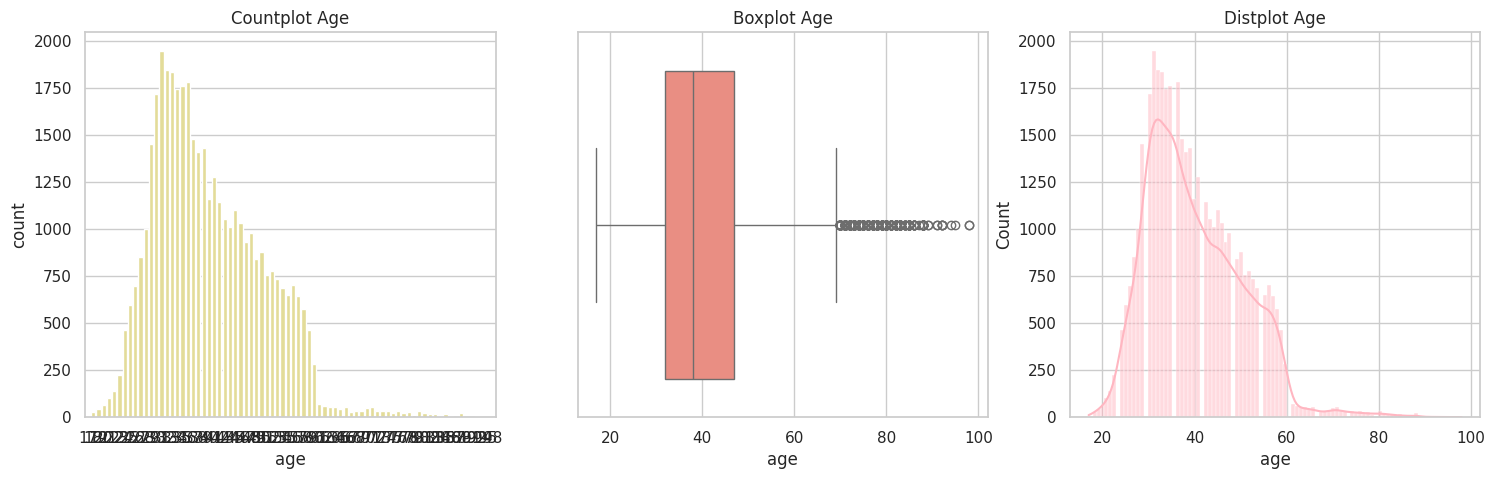

0.78
0.79


In [39]:
age_max =bank_client['age'].max()
print(age_max)
age_min=bank_client['age'].min()
print(age_min)

print(bank_client['age'].isnull().sum())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x=bank_client['age'], ax=axes[0], color='khaki')
axes[0].set_title('Countplot Age')

sns.boxplot(x=bank_client['age'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot Age')

sns.histplot(bank_client['age'], kde=True, ax=axes[2], color='lightpink')
axes[2].set_title('Distplot Age')

plt.show()

skewness = bank_client['age'].skew()
kurtosis = bank_client['age'].kurtosis()

print(f"{skewness:.2f}")
print(f"{kurtosis:.2f}")

**Висновки з 1-4 завдання (детальні)**

1. У першому щавданні ми можемо побачити що датасет не містить пропущених значень. Атрибути представлені як числові та категоріальні .
2. У другому завданні я вибрала y як target atributeб тому що оскільки вона відображає кінцевий результат кампанії.
3. У третьому завдання я виділила такі змінні як:age, job, marital, education, default.
4. Мінімальний вік – 17 років, максимальний – 98 років. Вибірка не містить пропущених значень у полі age. Розподіл age має легку асиметрію вправо та відносно низьку гостроту, що вказує на відсутність сильно виражених "важких хвостів".

**Завдання 5** Перевірити атрибут `Age` на викиди:

In [7]:
def detect_outliers_with_interquantile_range(df: pd.DataFrame,
                                             column: str,
                                             low_percentile: int,
                                             high_percentile: int) -> pd.DataFrame:
    """
    Detecting outliers using interquantile range set manually

    df: pd.DataFrame to detect outliers
    column: target column
    low_percentile: lower bound between 0 and 100
    high_percentile: upper bound between 0 and 100

    returns: pd.DataFrame with detected outliers

    """

    sorted_data = np.sort(df[column])
    # Calculate Q1, Q2, Q3 and IQR.
    Q1 = np.percentile(sorted_data, 25,interpolation = 'midpoint' )
    Q3 = np.percentile(sorted_data, 75,interpolation = 'midpoint')
    print('')
    print(f"Q1 {low_percentile} percentile of the given data: {Q1}")
    print('')
    print(f"Q3 {high_percentile} percentile of the given data: {Q3}")
    print('')
    print('----------------------------------------------------------')

    IQR = Q3 - Q1
    print('')
    print(f"Interquantile range: {IQR}")
    print('')
    print('----------------------------------------------------------')
    low_lim =  Q1 - 1.5 * IQR
    up_lim = Q3 + 1.5 * IQR
    print('')
    print(f" Lower bound: {low_lim}")
    print('')
    print(f" Upper bound: {up_lim}")
    print('')
    print('----------------------------------------------------------')
    outliers = df[(df[column] > up_lim) | (df[column] < low_lim)]
    print('')
    print(f"Outliers in the dataset:")
    display(outliers)


    return outliers

In [8]:
outliers = detect_outliers_with_interquantile_range(bank_client, 'age', 10, 90)


Q1 10 percentile of the given data: 32.0

Q3 90 percentile of the given data: 47.0

----------------------------------------------------------

Interquantile range: 15.0

----------------------------------------------------------

 Lower bound: 9.5

 Upper bound: 69.5

----------------------------------------------------------

Outliers in the dataset:


,age,job,marital,education,default,housing,loan
27713,70,retired,divorced,basic.4y,no,yes,no
27757,76,retired,married,university.degree,no,no,yes
27780,73,retired,married,university.degree,no,yes,no
27800,88,retired,divorced,basic.4y,no,yes,no
27802,88,retired,divorced,basic.4y,no,no,no
...,...,...,...,...,...,...,...
40986,84,retired,divorced,basic.4y,unknown,yes,yes
40996,81,retired,married,basic.4y,no,yes,no
41004,80,retired,married,professional.course,no,yes,no
41183,73,retired,married,professional.course,no,yes,no


**Висновки з завдання 5 (детальні)**

Можна побачити що нижня межа: 9.5 років, а верхня межа: 69.5 років. У наборі даних 469 клієнтів мають вік більше 69.5 років. В основному це пенсіонери з віком від 70 до 88 років. Виявлені викиди пов’язані з віковою групою пенсіонерів. Залежно від цілей дослідження, ці значення можна залишити або видалити.

**Завдання 6** Аналіз атрибутів `job`, `marital` та `education`:  
- Побудувати графіки розподілу даних по цим змінним.

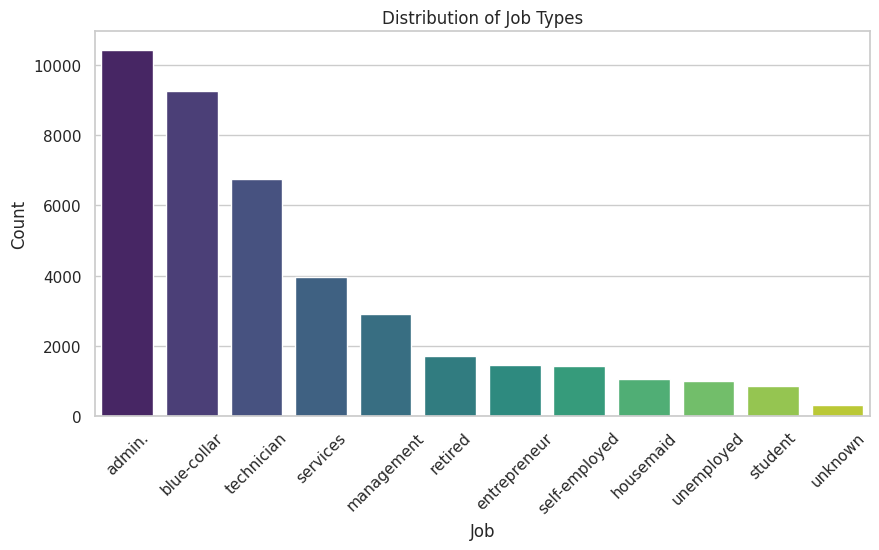

In [9]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.countplot(data=bank_client, x="job", order=bank_client["job"].value_counts().index, palette="viridis")
plt.title("Distribution of Job Types")
plt.xticks(rotation=45)
plt.xlabel("Job")
plt.ylabel("Count")
plt.show()

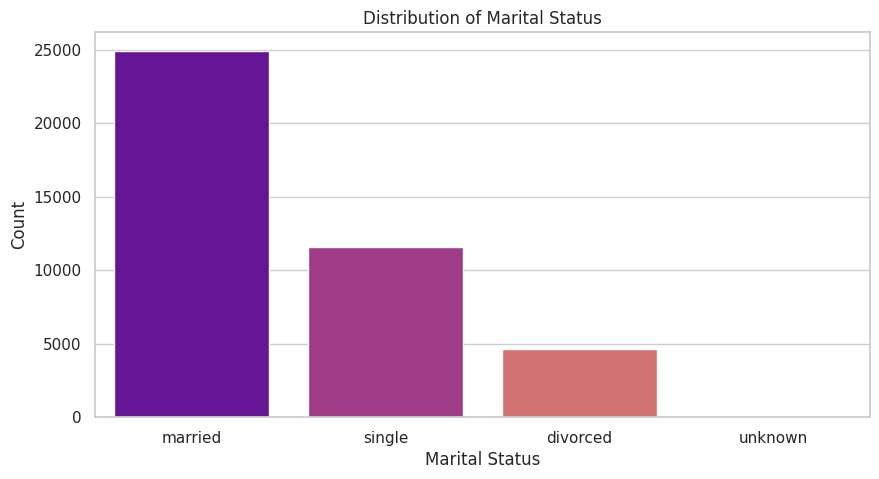

In [10]:
plt.figure(figsize=(10, 5))
sns.countplot(data=bank_client, x="marital", order=bank_client["marital"].value_counts().index, palette="plasma")
plt.title("Distribution of Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

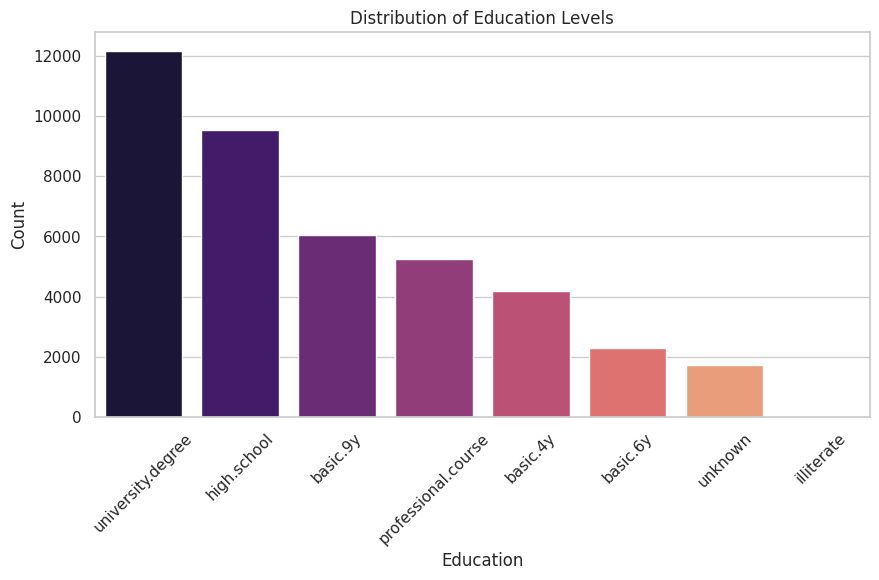

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(data=bank_client, x="education", order=bank_client["education"].value_counts().index, palette="magma")
plt.title("Distribution of Education Levels")
plt.xticks(rotation=45)
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

**Висновки з завдання 6 (детальні)**

1. На першому графіку можна побачити найбільша частка людей має вищу освіту .Друге місце займають особи з середньою освітою. Найменшу кількість складають неписемні  та ті, чий рівень освіти невідомий .  
2. На другому графіку можна побачити, що найбільше людей у вибірці є одруженими , що може свідчити про більш старший вік респондентів. Значна частка складається з самотніх .Розлучені та особи з невизначеним статусом  зустрічаються значно рідше.  

3. На третьому графіку можна побачити, що найпоширеніші професії: адміни , робітники (blue-collar) та технічні спеціалісти . Найменше представників серед студентів , безробітних та осіб із невідомим типом роботи. Також помітна частка пенсіонерів  та осіб, зайнятих у сфері менеджменту , послуг  та підприємництва .

**Завдання 7** Аналіз атрибутів `default`, `housing` та `loan`:  
- Побудувати графіки розподілу даних по цим змінним.

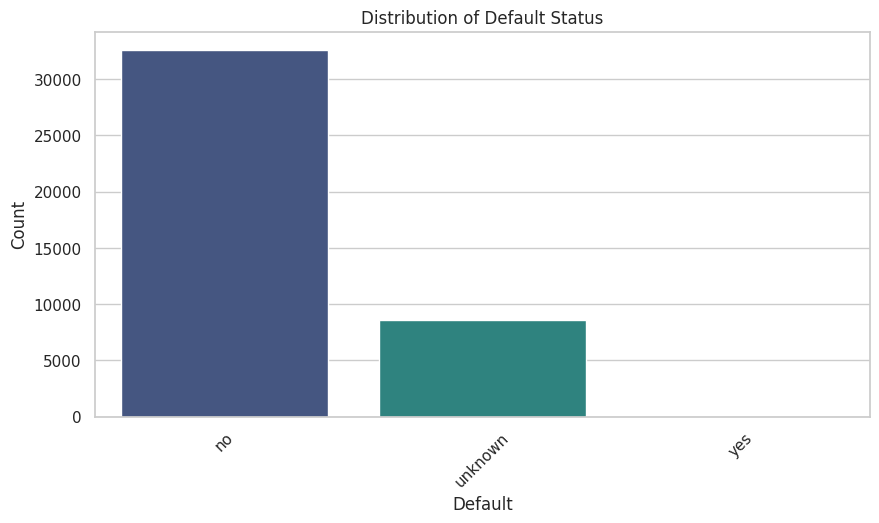

In [12]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.countplot(data=bank_client, x="default", order=bank_client["default"].value_counts().index, palette="viridis")
plt.title("Distribution of Default Status")
plt.xticks(rotation=45)
plt.xlabel("Default")
plt.ylabel("Count")
plt.show()

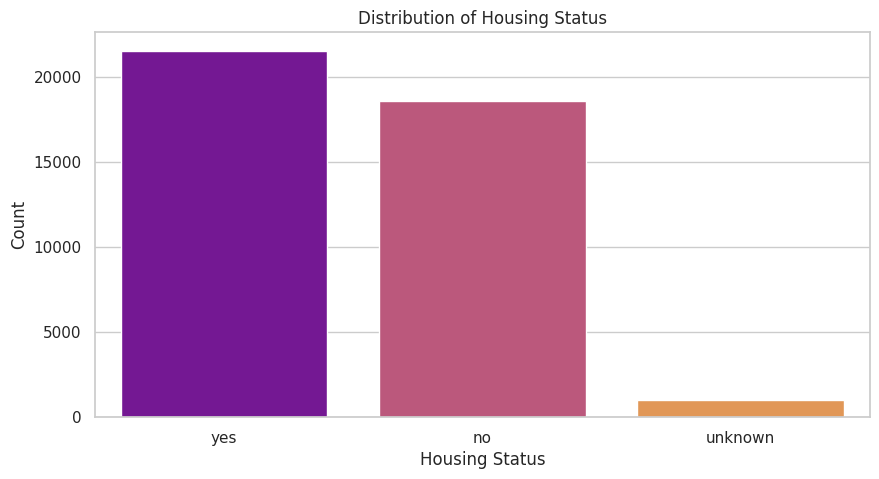

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(data=bank_client, x="housing", order=bank_client["housing"].value_counts().index, palette="plasma")
plt.title("Distribution of Housing Status")
plt.xlabel("Housing Status")
plt.ylabel("Count")
plt.show()

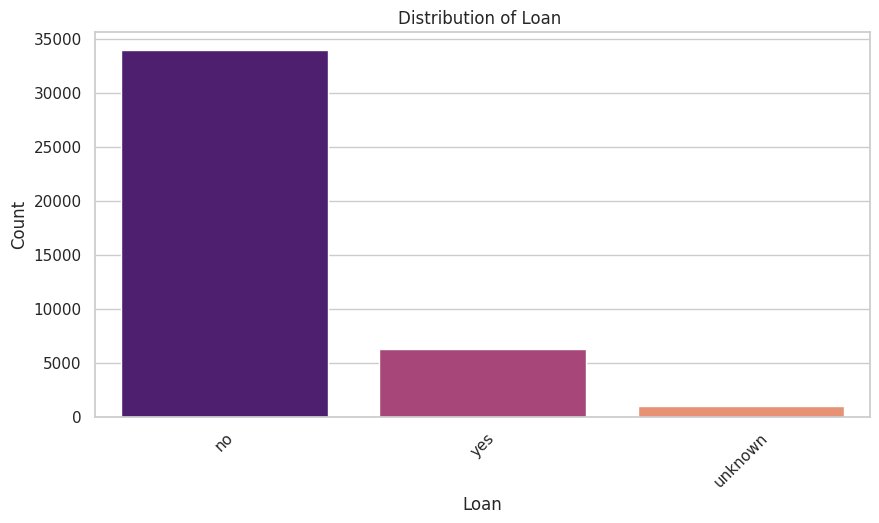

In [14]:
plt.figure(figsize=(10, 5))
sns.countplot(data=bank_client, x="loan", order=bank_client["loan"].value_counts().index, palette="magma")
plt.title("Distribution of Loan ")
plt.xticks(rotation=45)
plt.xlabel("Loan")
plt.ylabel("Count")
plt.show()

**Завдання 8** Змінні **Jobs, Marital, Education, Default, Housing, Loan** трансформувати в неперервні змінні:

In [15]:
def encode_categorical_columns(df: pd.DataFrame, categorical_cols: list) -> pd.DataFrame:
    """
    Function for encoding categorical features using LabelEncoder

    df: pd.DataFrame to encode
    categorical_cols: specified columns to encode

    returns: pd.DataFrame with encoded values
    """
    for col in categorical_cols:
        le = LabelEncoder()
        not_null = df[col][df[col].notnull()]
        df[col] = df[col].astype('category').cat.codes

    return df

In [16]:
bank_client = encode_categorical_columns(bank_client, ['job', 'marital', 'education', 'default', 'housing',  'loan'])
print(bank_client)

       age  job  marital  education  default  housing  loan
0       56    3        1          0        0        0     0
1       57    7        1          3        1        0     0
2       37    7        1          3        0        2     0
3       40    0        1          1        0        0     0
4       56    7        1          3        0        0     2
...    ...  ...      ...        ...      ...      ...   ...
41183   73    5        1          5        0        2     0
41184   46    1        1          5        0        0     0
41185   56    5        1          6        0        2     0
41186   44    9        1          5        0        0     0
41187   74    5        1          5        0        2     0

[41188 rows x 7 columns]


**Завдання 9** Трансфомувати змінну **Age** (використовуючи її квартильні значення):




In [17]:
def encode_age(dataframe: pd.DataFrame, age_col: str ) -> pd.DataFrame:
  """
  Function for encoding age column

  df: pd.DataFrame to encode
  age_col: age col to encode
  """
  quartiles = dataframe[age_col].quantile([0.25, 0.5, 0.75])

  def categorize_age(age):
        if age <= quartiles[0.25]:
            return 'young'
        elif age <= quartiles[0.5]:
            return 'middle_young'
        elif age <= quartiles[0.75]:
            return 'middle_old'
        else:
            return 'old'

  dataframe[age_col + '_encode'] = dataframe[age_col].apply(categorize_age)

  return dataframe

In [18]:
bank_client = encode_age(bank_client, 'age')
print(bank_client['age_encode'])

0                 old
1                 old
2        middle_young
3          middle_old
4                 old
             ...     
41183             old
41184      middle_old
41185             old
41186      middle_old
41187             old
Name: age_encode, Length: 41188, dtype: object


**Висновки з завдання 9 (детальні)** перевірити як відбулося перетворення змінних

## Вибірка містить певну кількість атрибутів, які характеризують останій зв'язок кліентів з банком

**Завдання 10** Виділити в окремий датафрейм змінні, які характеризують зв'язок клієнтів з банком;
- вивести цей датафрейм;
- перевірити ці змінні на `NaN`.

In [19]:
bank_relat =  bank_data[['default', 'housing', 'loan','duration']]
print(bank_relat.head())
print(bank_relat.head())

   default housing loan  duration
0       no      no   no       261
1  unknown      no   no       149
2       no     yes   no       226
3       no      no   no       151
4       no      no  yes       307
   default housing loan  duration
0       no      no   no       261
1  unknown      no   no       149
2       no     yes   no       226
3       no      no   no       151
4       no      no  yes       307


**Завдання 11** вивести унікальні значення, які містять атрибути `contact`, `month`, `day_of_week`

In [20]:
print(bank_data["contact"].unique())
print( bank_data["month"].unique())
print(bank_data["day_of_week"].unique())

['telephone' 'cellular']
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
['mon' 'tue' 'wed' 'thu' 'fri']


# Провести аналіз змінної **Duration**

змінна ` duration` містить інформацію про тривалість останнього дзвінка, в секундах (числова). Важливе зауваження: цей атрибут сильно впливає на цільову змінну (наприклад, якщо тривалість = 0, тоді y = "ні"). Проте тривалість невідома до здійснення дзвінка. Крім того, після закінчення дзвінка y, очевидно, відомо. Таким чином, цей внесок слід включати лише для цілей порівняльних показників і відкидати, якщо метою є реалістична модель прогнозування.

**Завдання 12** Аналіз атрибуту `duration`:  

Провести візуальний аналіз зміної `duration`:  


*   побудувати  `boxplot` та `distplot`;
*   перевірити розподіл по змінній `duration` на важкі хвости.



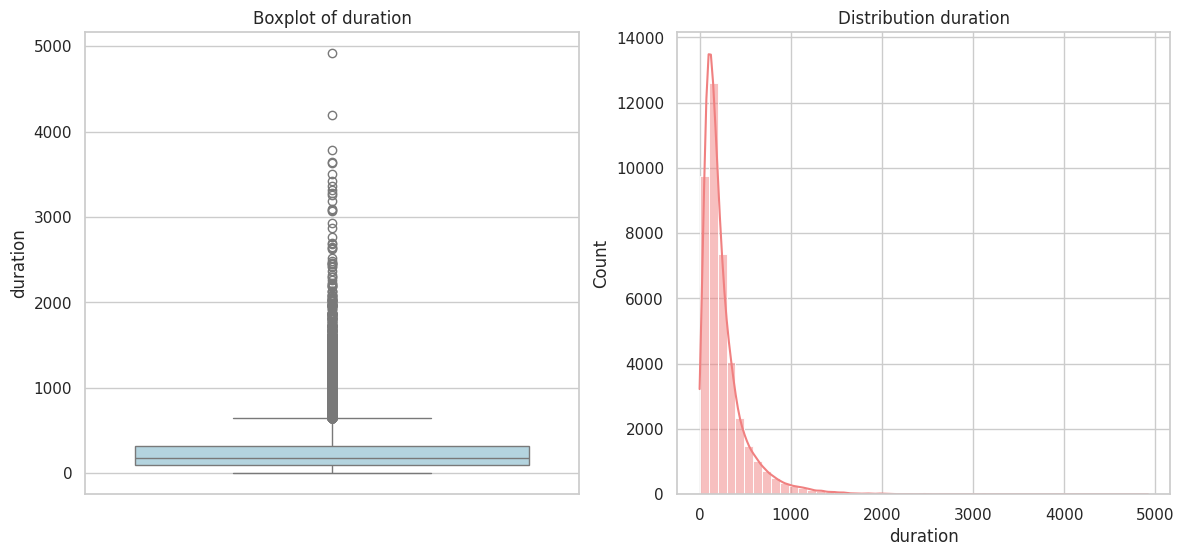

count    41188.000000
mean       258.285010
std        259.279249
min          0.000000
25%        102.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64


In [21]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(y=bank_data["duration"], ax=axes[0], color="lightblue")
axes[0].set_title("Boxplot of duration")

sns.histplot(bank_data["duration"], kde=True, bins=50, ax=axes[1], color="lightcoral")
axes[1].set_title("Distribution duration")

plt.show()

print(bank_data["duration"].describe())

**Завдання 13** Закодувати змінні Contact, Month, Day of Week (використовуйте функцію `encode_categorical_columns()`)

In [22]:
bank_date = encode_categorical_columns(bank_data, ['contact', 'month',  'day_of_week'])
print(bank_date)

       age          job  marital            education  default housing loan  \
0       56    housemaid  married             basic.4y       no      no   no   
1       57     services  married          high.school  unknown      no   no   
2       37     services  married          high.school       no     yes   no   
3       40       admin.  married             basic.6y       no      no   no   
4       56     services  married          high.school       no      no  yes   
...    ...          ...      ...                  ...      ...     ...  ...   
41183   73      retired  married  professional.course       no     yes   no   
41184   46  blue-collar  married  professional.course       no      no   no   
41185   56      retired  married    university.degree       no     yes   no   
41186   44   technician  married  professional.course       no      no   no   
41187   74      retired  married  professional.course       no     yes   no   

       contact  month  day_of_week  ...  campaign  

**Завдання 14** Трансфомувати змінну **duration**, використовуючи її квартильні значення:

In [23]:
def encode_duration(dataframe: pd.DataFrame, duration_col: str ) -> pd.DataFrame:
  """
  Function for encoding duration column

  df: pd.DataFrame to encode
  duration_col: duration col to encode
  """

  quartiles = dataframe[duration_col].quantile([0.25, 0.5, 0.75])

  def categorize_duration(duration):
        if duration <= quartiles[0.25]:
            return 'short'
        elif duration <= quartiles[0.5]:
            return 'middle_short'
        elif duration <= quartiles[0.75]:
            return 'middle_long'
        else:
            return 'long'

  dataframe[duration_col + '_encode'] = dataframe[duration_col].apply(categorize_duration)

  return dataframe

In [24]:
bank_relat = encode_duration(bank_relat, 'duration')
print(bank_relat)

       default housing loan  duration duration_encode
0           no      no   no       261     middle_long
1      unknown      no   no       149    middle_short
2           no     yes   no       226     middle_long
3           no      no   no       151    middle_short
4           no      no  yes       307     middle_long
...        ...     ...  ...       ...             ...
41183       no     yes   no       334            long
41184       no      no   no       383            long
41185       no     yes   no       189     middle_long
41186       no      no   no       442            long
41187       no     yes   no       239     middle_long

[41188 rows x 5 columns]


## Провести аналіз атрибутів **соціального та економічного контексту**

**Завдання 15** Виділити в окремий датафрейм атрибути соціального та єкономічного контексту

 emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

In [25]:
bank_socec =  bank_data[['emp.var.rate', 'cons.price.idx', 'cons.conf.idx','euribor3m','nr.employed']]
print(bank_socec)

       emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed
0               1.1          93.994          -36.4      4.857       5191.0
1               1.1          93.994          -36.4      4.857       5191.0
2               1.1          93.994          -36.4      4.857       5191.0
3               1.1          93.994          -36.4      4.857       5191.0
4               1.1          93.994          -36.4      4.857       5191.0
...             ...             ...            ...        ...          ...
41183          -1.1          94.767          -50.8      1.028       4963.6
41184          -1.1          94.767          -50.8      1.028       4963.6
41185          -1.1          94.767          -50.8      1.028       4963.6
41186          -1.1          94.767          -50.8      1.028       4963.6
41187          -1.1          94.767          -50.8      1.028       4963.6

[41188 rows x 5 columns]


**Завдання 16** Виділити в окремий датафрейм всі інші атрибути атрибути - `campaign`, `pdays`,`previous`, `poutcome`

In [26]:
bank_other =  bank_data[['campaign', 'pdays', 'previous','poutcome']]
print(bank_other)

       campaign  pdays  previous     poutcome
0             1    999         0  nonexistent
1             1    999         0  nonexistent
2             1    999         0  nonexistent
3             1    999         0  nonexistent
4             1    999         0  nonexistent
...         ...    ...       ...          ...
41183         1    999         0  nonexistent
41184         1    999         0  nonexistent
41185         2    999         0  nonexistent
41186         1    999         0  nonexistent
41187         3    999         1      failure

[41188 rows x 4 columns]


**Завдання 17** Провести трансформацію атрибуту `poutcome`

In [27]:
def transform_poutcome(df: pd.DataFrame, method="label") -> pd.DataFrame:
    """
    Function to transform 'poutcome' attribute.

    df (pd.DataFrame): Input dataframe
    method (str): Encoding method ('label', 'onehot', or 'binary')
    pd.DataFrame: Transformed dataframe
    """

    if method == "label":
        df["poutcome_encoded"] = LabelEncoder().fit_transform(df["poutcome"])

    elif method == "onehot":
        df = pd.get_dummies(df, columns=["poutcome"], prefix="poutcome")

    elif method == "binary":
        df["poutcome_encoded"] = df["poutcome"].apply(lambda x: 1 if x == "success" else 0)

    return df


df = transform_poutcome(bank_data, method="label")

print(bank_data[["poutcome", "poutcome_encoded"]].head())

      poutcome  poutcome_encoded
0  nonexistent                 1
1  nonexistent                 1
2  nonexistent                 1
3  nonexistent                 1
4  nonexistent                 1


## Будування моделей класифікації

**Завдання 18** З'єднати всі отримані блоки в один датафрейм і перевірити, що він містить тільки потрібні для моделювання колонки

In [28]:
bank_final= bank_data[['age', 'job', 'marital', 'education', 'default', 'housing', 'loan','contact', 'month', 'day_of_week', 'duration','y' ,'poutcome_encoded']]
print(bank_final)

       age          job  marital            education  default housing loan  \
0       56    housemaid  married             basic.4y       no      no   no   
1       57     services  married          high.school  unknown      no   no   
2       37     services  married          high.school       no     yes   no   
3       40       admin.  married             basic.6y       no      no   no   
4       56     services  married          high.school       no      no  yes   
...    ...          ...      ...                  ...      ...     ...  ...   
41183   73      retired  married  professional.course       no     yes   no   
41184   46  blue-collar  married  professional.course       no      no   no   
41185   56      retired  married    university.degree       no     yes   no   
41186   44   technician  married  professional.course       no      no   no   
41187   74      retired  married  professional.course       no     yes   no   

       contact  month  day_of_week  duration    y  

**Завдання 19** Провести ділення вибірки

In [29]:
def prepare_data_for_training(X: pd.DataFrame,
                              target: pd.Series,
                              test_size: float,
                              n_splits: int,
                              random_state: int):
    """
    Function that prepares data for training. Splits the data into train and test datasets and get k-folds for cross-validation

    X: pd.DataFrame with features
    target: target pd.Series
    test_size: the size of test datasets
    n_splits: number of cross-validation splits
    random_state: random state to reproduce the same split

    returns: X_train, X_test, y_train, y_test, k_fold
    """

    X_train, X_test, y_train, y_test =  train_test_split (X, target, test_size=test_size, random_state=random_state)
    k_fold = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    return X_train, X_test, y_train, y_test, k_fold

In [30]:
target = bank_final['y']
X_train, X_test, y_train, y_test, k_fold = prepare_data_for_training(bank_final, target, 0.2, 10, 101)

In [31]:
def scale_the_data(X_train: pd.DataFrame,
                   X_test: pd.DataFrame):

  numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
  categorical_cols = X_train.select_dtypes(include=['object']).columns

  sc_X = StandardScaler()
  X_train[numerical_cols] = sc_X.fit_transform(X_train[numerical_cols])
  X_test[numerical_cols] = sc_X.transform(X_test[numerical_cols])

  label_encoder = LabelEncoder()

  for col in categorical_cols:
        X_train[col] = label_encoder.fit_transform(X_train[col].astype(str))
        X_test[col] = label_encoder.transform(X_test[col].astype(str))

  return X_train, X_test

In [32]:
X_train, X_test = scale_the_data(X_train, X_test)

## Логістична Регресія

In [33]:
logmodel = LogisticRegression()
logmodel.fit(X_train, y_train)
logpred = logmodel.predict(X_test)


print(confusion_matrix(y_test, logpred))
print(round(accuracy_score(y_test, logpred),2)*100)
LOGCV = (cross_val_score(logmodel, X_test, y_test, cv=k_fold, n_jobs=1, scoring = 'accuracy').mean())

[[7279    0]
 [   0  959]]
100.0


## k-NN

k=2 92.48 (+/- 0.46)
k=3 93.86 (+/- 0.42)
k=4 92.66 (+/- 0.52)
k=5 93.44 (+/- 0.46)
k=6 92.60 (+/- 0.47)
k=7 93.09 (+/- 0.47)
k=8 92.60 (+/- 0.43)
k=9 92.99 (+/- 0.54)
k=10 92.39 (+/- 0.51)
k=11 92.78 (+/- 0.43)
k=12 92.30 (+/- 0.43)
k=13 92.56 (+/- 0.45)
k=14 92.22 (+/- 0.47)
k=15 92.41 (+/- 0.53)
k=16 92.11 (+/- 0.53)
k=17 92.32 (+/- 0.60)
k=18 92.02 (+/- 0.58)
k=19 92.19 (+/- 0.60)
k=20 91.92 (+/- 0.61)
k=21 92.10 (+/- 0.60)
k=22 91.85 (+/- 0.59)
k=23 91.99 (+/- 0.60)
k=24 91.75 (+/- 0.58)
k=25 91.89 (+/- 0.60)
The optimal number of neighbors is 2 with 92.7%


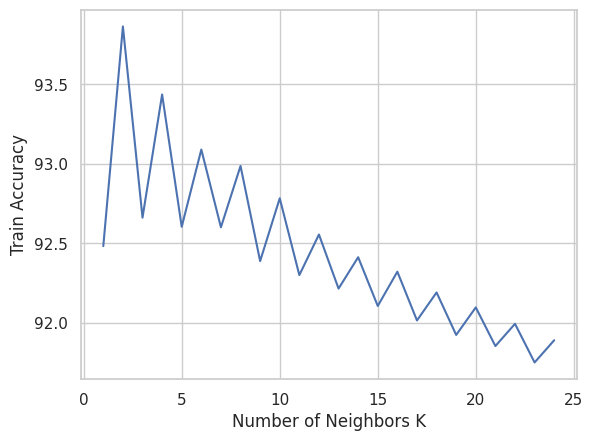

In [35]:
#Neighbors
neighbors = np.arange(1,25)

#Create empty list that will hold cv scores
cv_scores = []

#Perform 10-fold cross validation on training set for odd values of k:
for k in neighbors:
    k_value = k+1
    knn = KNeighborsClassifier(n_neighbors = k_value, weights='uniform', p=2, metric='euclidean')
    scores = model_selection.cross_val_score(knn, X_train, y_train, cv=k_fold, scoring='accuracy')
    cv_scores.append(scores.mean()*100)
    print("k=%d %0.2f (+/- %0.2f)" % (k_value, scores.mean()*100, scores.std()*100))

optimal_k = neighbors[cv_scores.index(max(cv_scores))]
print ("The optimal number of neighbors is %d with %0.1f%%" % (optimal_k, cv_scores[optimal_k]))

plt.plot(neighbors, cv_scores)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Train Accuracy')
plt.show()

In [36]:
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)
knnpred = knn.predict(X_test)

print(confusion_matrix(y_test, knnpred))
print(round(accuracy_score(y_test, knnpred),2)*100)
KNNCV = (cross_val_score(knn, X_test, y_test, cv=k_fold, n_jobs=1, scoring = 'accuracy').mean())

[[7239   40]
 [ 554  405]]
93.0


## Логістична Регресія

In [41]:
models = pd.DataFrame({
                'Models':['Logistic Regression', 'KNN'],
                'Score': [LOGCV, KNNCV]})

models.sort_values(by='Score', ascending=False)

,Models,Score
0,Logistic Regression,1.000000
1,KNN,0.909932


**Висновки по моделям (детальні)**

1. Логістична регресія показала дуже високу точність на тестовій вибірці, але це може бути ознакою перенавчання. Тобто, модель добре працює на тестових даних, але її узагальнювальна здатність під питанням.
2. Метод K-найближчих сусідів  показав трохи нижчу точність, але він має кращу узагальнювальну здатність. Проте в моделі є помилки, зокрема 554 випадки, коли модель неправильно класифікувала дані.  
3. Обидві моделі показали хороші результати